# 한국어 감성 챗봇 구현
## Seq2Seq + Decoding Strategy 비교

- 데이터셋 : Chatbot_data_for_Korean v1.0 (11,876 문답 쌍)
- 베이스 코드 : 120_ChatBot_EncoderDecoder_sentencepiece.ipynb
- 핵심 실험 : Greedy vs Beam Search (Width=3, 5, 10) 비교

## STEP 0 — 환경 설정

> Colab 메뉴 → 런타임 → 런타임 유형 변경 → **GPU** 선택 권장

In [1]:
# 셀 1: 필수 패키지 설치
!pip install -q sentencepiece
!pip install -q nltk

In [2]:
# 셀 2: 전체 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import tensorflow as tf
import sentencepiece as spm

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)

print('TensorFlow:', tf.__version__)
print('GPU 사용 가능:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.0
GPU 사용 가능: True


In [3]:
# 셀 3: 하이퍼파라미터 (한 곳에 모아 관리)
LATENT_DIM    = 128    # LSTM hidden state 크기
EMBEDDING_DIM = 100    # 임베딩 차원
VOCAB_SIZE    = 5000   # SentencePiece 어휘 크기
MAX_LEN       = 30     # 시퀀스 최대 길이
BATCH_SIZE    = 64
EPOCHS        = 100

# 특수 토큰 ID
PAD_ID = 0  # <pad>
BOS_ID = 1  # <s>  : 문장 시작
EOS_ID = 2  # </s> : 문장 끝
UNK_ID = 3  # <unk>: 미등록 단어

print('하이퍼파라미터 설정 완료')

하이퍼파라미터 설정 완료


## STEP 1 — 데이터 로드 및 탐색

In [4]:
# 셀 4: 데이터 로드
df = pd.read_csv('https://raw.github.com/ironmanciti/Infran_NLP/master/data/ChatbotData.csv')
print('shape:', df.shape)   # (11876, 3)
print(df.head())
# 컬럼: Q (질문) / A (답변) / label (감정 0~2)
# label 0: 일상 대화, 1: 이별/슬픔, 2: 연애/기쁨

shape: (11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


감정 레이블 분포:
label
0    5290
1    3570
2    2963
Name: count, dtype: int64

질문/답변 길이 통계:
              Q_len         A_len
count  11823.000000  11823.000000
mean      12.879049     15.015140
std        6.167467      6.701835
min        1.000000      1.000000
25%        9.000000     10.000000
50%       12.000000     14.000000
75%       16.000000     18.000000
max       56.000000     76.000000


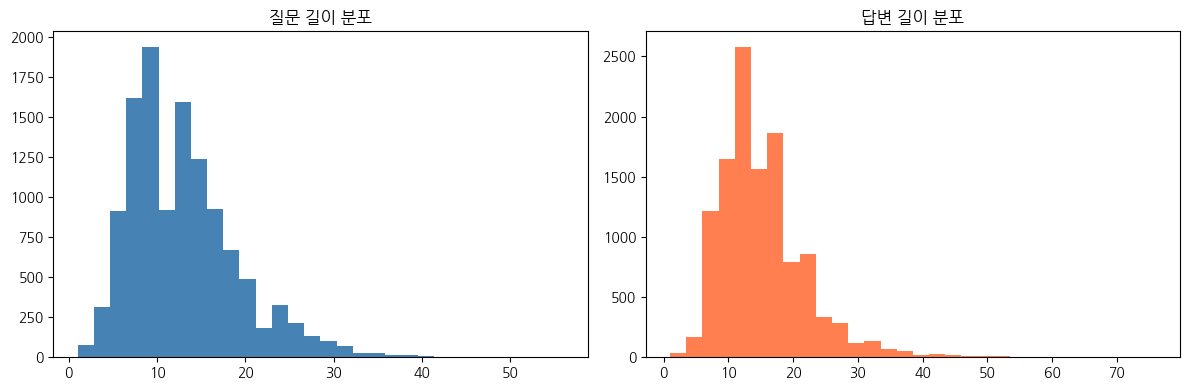

In [5]:
# 셀 5: 기본 탐색

# 한글 폰트 설정
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
print('감정 레이블 분포:')
print(df['label'].value_counts())

# 질문/답변 길이 분포
df['Q_len'] = df['Q'].apply(len)
df['A_len'] = df['A'].apply(len)
print('\n질문/답변 길이 통계:')
print(df[['Q_len', 'A_len']].describe())

# 길이 분포 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Q_len'], bins=30, color='steelblue')
plt.title('질문 길이 분포')
plt.subplot(1, 2, 2)
plt.hist(df['A_len'], bins=30, color='coral')
plt.title('답변 길이 분포')
plt.tight_layout()
plt.show()

In [6]:
# 셀 6: Q/A 리스트 생성
Q_texts   = df['Q'].tolist()
A_texts   = df['A'].tolist()
All_texts = Q_texts + A_texts   # SentencePiece 학습용

print(f'Q: {len(Q_texts)}개, A: {len(A_texts)}개')
print('Q 샘플:', Q_texts[:3])
print('A 샘플:', A_texts[:3])

Q: 11823개, A: 11823개
Q 샘플: ['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
A 샘플: ['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


## STEP 2 — SentencePiece 토크나이저 학습

일반 Tokenizer는 신조어, 줄임말 등 미등록 단어를 `<UNK>`로 처리한다.  
SentencePiece는 서브워드 단위로 분해하여 UNK를 최소화하고 사전 크기를 고정할 수 있어 챗봇에 적합하다.

In [7]:
# 셀 7: 학습 텍스트 파일 저장
with open('chatbot_qna.txt', 'w', encoding='utf-8') as f:
    for line in All_texts:
        f.write(line + '\n')
print('텍스트 파일 저장 완료')

텍스트 파일 저장 완료


In [8]:
# 셀 8: SentencePiece 학습
cmd = (
    f'--input=chatbot_qna.txt '
    f'--model_prefix=chatbot_spm '
    f'--vocab_size={VOCAB_SIZE} '
    f'--pad_id={PAD_ID} '
    f'--bos_id={BOS_ID} '
    f'--eos_id={EOS_ID} '
    f'--unk_id={UNK_ID}'
)
spm.SentencePieceTrainer.Train(cmd)
print('SentencePiece 학습 완료!')

SentencePiece 학습 완료!


In [9]:
# 셀 9: 토크나이저 로드 및 확인
sp_model = spm.SentencePieceProcessor()
sp_model.Load('chatbot_spm.model')

# 인코딩 테스트
test = '오늘 날씨가 너무 좋아서 기분이 최고야'
print('원문  :', test)
print('토큰  :', sp_model.encode_as_pieces(test))
print('ID    :', sp_model.encode_as_ids(test))

원문  : 오늘 날씨가 너무 좋아서 기분이 최고야
토큰  : ['▁오늘', '▁날씨', '가', '▁너무', '▁좋아', '서', '▁기분이', '▁최고', '야']
ID    : [78, 606, 7, 22, 118, 25, 620, 1348, 81]


In [10]:
# 셀 10: Q 시퀀스 (BOS/EOS 없음 — Encoder 입력)
sp_model.SetEncodeExtraOptions('')
Q_sequences = [sp_model.encode_as_ids(sent) for sent in Q_texts]

# 셀 11: A 입력 시퀀스 (BOS 추가 — Decoder 입력, Teacher Forcing용)
sp_model.SetEncodeExtraOptions('bos:')
A_sequences_inputs = [sp_model.encode_as_ids(sent) for sent in A_texts]

# 셀 12: A 목표 시퀀스 (EOS 추가 — Decoder target)
sp_model.SetEncodeExtraOptions(':eos')
A_sequences_targets = [sp_model.encode_as_ids(sent) for sent in A_texts]

print('Q  예시:', Q_sequences[0])
print('A 입력 :', A_sequences_inputs[0])   # 1(BOS)로 시작
print('A 목표 :', A_sequences_targets[0])  # 2(EOS)로 끝

Q  예시: [4228, 299, 5, 4826, 72]
A 입력 : [1, 282, 7, 113, 82, 23, 4]
A 목표 : [282, 7, 113, 82, 23, 4, 2]


## STEP 3 — 시퀀스 변환 및 패딩

⚠️ 패딩 방향 주의
- **Encoder 입력**: `padding='pre'` (default) → Thought Vector 품질 향상
- **Decoder 입력**: `padding='post'` → Teacher Forcing이 올바르게 동작

In [11]:
# 셀 13: 패딩 적용
# ⚠️ 패딩 방향이 Encoder와 Decoder에서 달라야 한다.
#
# Encoder (pre padding — 앞에 0 채움):
#   LSTM이 시퀀스를 읽고 마지막 hidden state를 Thought Vector로 쓰기 때문에
#   앞에 0이 붙어도 실제 단어를 읽는 순서에 영향이 없다.
#   → 마지막 hidden state 품질 유지
#
# Decoder (post padding — 뒤에 0 채움):
#   Teacher Forcing으로 단어를 순서대로 넣어야 하기 때문에
#   앞에 0을 붙이면 BOS 위치가 밀려 Teacher Forcing 순서가 깨진다.
#   → 뒤에 0을 채워 BOS 위치 고정

# Encoder: pre 패딩 (padding 인자 생략 시 default='pre')
encoder_inputs  = pad_sequences(Q_sequences,         maxlen=MAX_LEN)
# Decoder 입력: post 패딩
decoder_inputs  = pad_sequences(A_sequences_inputs,  maxlen=MAX_LEN, padding='post')
# Decoder 목표: post 패딩
decoder_targets = pad_sequences(A_sequences_targets, maxlen=MAX_LEN, padding='post')

print('Encoder input  shape:', encoder_inputs.shape)   # (11876, 30)
print('Decoder input  shape:', decoder_inputs.shape)   # (11876, 30)
print('Decoder target shape:', decoder_targets.shape)  # (11876, 30)

print('\nEncoder 샘플[0]:', encoder_inputs[0])    # 앞에 0이 채워진 형태
print('Decoder 입력[0]:', decoder_inputs[0])   # 1(BOS)로 시작, 뒤에 0 채움
print('Decoder 목표[0]:', decoder_targets[0])  # 2(EOS)로 끝, 뒤에 0 채움


Encoder input  shape: (11823, 30)
Decoder input  shape: (11823, 30)
Decoder target shape: (11823, 30)

Encoder 샘플[0]: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0 4228  299    5
 4826   72]
Decoder 입력[0]: [  1 282   7 113  82  23   4   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]
Decoder 목표[0]: [282   7 113  82  23   4   2   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


## STEP 4 — Seq2Seq 모델 구성

```
입력 Q 시퀀스 (batch, 30)
       ↓
  [Embedding] → (batch, 30, 100)
       ↓
 [Encoder LSTM] return_state=True
       ↓
 [h, c] = Thought Vector (batch, 128) × 2
       ↓ (초기 상태로 전달)
 [Decoder LSTM] return_sequences=True
       ↓
 [Dense + Softmax] → (batch, 30, 5001)
       ↓
  예측 단어 확률
```

In [12]:
# 셀 14: Encoder 구현
# Encoder는 학습(Training)과 추론(Inference) 단계 모두에서 사용된다.
# 입력 시퀀스 전체를 읽고 마지막 hidden state [h, c]만 Decoder로 전달한다.
# 이 [h, c]가 문장 전체의 의미를 압축한 Thought Vector다.

encoder_inputs_ = Input(shape=(MAX_LEN,), name='Encoder_Input')

# Embedding: 정수 인덱스를 EMBEDDING_DIM 차원의 밀집 벡터로 변환
# VOCAB_SIZE + 1을 쓰는 이유: pad_id=0이 인덱스 0을 차지하므로 1 추가
embedding_encoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_encoder(encoder_inputs_)

# LSTM: return_state=True로 설정해 마지막 hidden state h, c를 반환
# encoder_outputs는 사용하지 않고 [h, c]만 Decoder로 넘긴다
encoder_outputs, h, c = LSTM(LATENT_DIM, return_state=True, name='Encoder_LSTM')(x)
encoder_states = [h, c]   # Thought Vector

# 추론용 Encoder 모델: 입력 시퀀스를 받아 [h, c]만 출력
# 학습 완료 후 이 모델로 Thought Vector를 추출해 Decoder에 전달한다
encoder_model = Model(encoder_inputs_, encoder_states, name='Encoder_Model')
encoder_model.summary()

Model: "Encoder_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder_Input (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 100)        │       500,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_LSTM (LSTM)             │ [(None, 128), (None,   │       117,248 │
│                                 │ 128), (None, 128)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,348 (2.35 MB)

 Trainable params: 617,348 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 셀 15: Decoder 구현 (학습용 — Teacher Forcing 적용)
# Teacher Forcing: 학습 시 모델의 예측값 대신 실제 정답(A_input)을 다음 step 입력으로 사용
# 오류 누적을 방지하고 학습 초반 수렴 속도를 높이는 효과가 있다.
# 단, 실제 추론 시에는 정답을 알 수 없으므로 학습/추론 사이에 입력 방식 차이(Exposure Bias)가 발생한다.

decoder_inputs_ = Input(shape=(MAX_LEN,), name='Decoder_Input')

# Decoder는 Encoder와 별도의 Embedding을 사용한다.
# 한국어 Q와 한국어 A가 같은 언어지만, 문맥이 달라 별도 학습하는 것이 일반적이다.
embedding_decoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_decoder(decoder_inputs_)

# return_sequences=True: 매 step마다 출력이 필요하기 때문 (각 단어 예측)
# return_state=True: 추론용 decoder_model에서 이전 step의 state를 재사용하기 위해
# initial_state=encoder_states: Encoder의 Thought Vector [h, c]를 초기 hidden state로
decoder_lstm = LSTM(LATENT_DIM, return_sequences=True,
                    return_state=True, name='Decoder_LSTM')
decoder_out, _, _ = decoder_lstm(x, initial_state=encoder_states)

# Dense + Softmax: LSTM 출력을 어휘 사전 크기(VOCAB_SIZE+1)만큼의 확률로 변환
# 각 step에서 다음 단어의 확률 분포를 출력한다
decoder_dense   = Dense(VOCAB_SIZE + 1, activation='softmax', name='Output_Dense')
decoder_outputs = decoder_dense(decoder_out)

# 학습용 통합 모델: [Q, A_input] → A_target
# sparse_categorical_crossentropy: target이 one-hot이 아닌 정수 인덱스 형태일 때 사용
model_teacher_forcing = Model(
    [encoder_inputs_, decoder_inputs_],
    decoder_outputs,
    name='Seq2Seq_Train'
)
model_teacher_forcing.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_teacher_forcing.summary()

Model: "Seq2Seq_Train"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 100)   │    500,100 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 30, 100)   │    500,100 │ Decoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_LSTM (LSTM) │ [(None, 128),     │    117,248 │ embedding[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 30, 128), │    117,248 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ Encoder_LSTM[0][… │
│                     │ (None, 128)]      │            │ Encoder_LSTM[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Dense        │ (None, 30, 5001)  │    645,129 │ Decoder_LSTM[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,879,825 (7.17 MB)

 Trainable params: 1,879,825 (7.17 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 셀 16: 추론용 Decoder 모델 분리
# 학습 모델과 추론 모델을 분리하는 이유:
# 학습 시에는 전체 A_input 시퀀스를 한 번에 넣지만,
# 추론 시에는 단어를 하나씩 생성하면서 이전 step의 [h, c]를 다음 step에 전달해야 한다.
# 따라서 단어 하나를 입력받아 다음 단어 + 새로운 [h, c]를 반환하는 구조가 필요하다.
# 학습된 가중치(embedding_decoder, decoder_lstm, decoder_dense)를 그대로 재사용한다.

# 이전 step에서 넘어온 hidden state, cell state를 입력으로 받는다
decoder_state_input_h  = Input(shape=(LATENT_DIM,), name='Dec_h')
decoder_state_input_c  = Input(shape=(LATENT_DIM,), name='Dec_c')
decoder_states_inputs  = [decoder_state_input_h, decoder_state_input_c]

# 한 번에 단어 하나씩 입력 (shape=(1,))
decoder_inputs_single  = Input(shape=(1,), name='Dec_Single_Input')
x = embedding_decoder(decoder_inputs_single)   # 학습 시 사용한 embedding 레이어 재사용

# decoder_lstm도 학습 시 사용한 레이어 재사용 → 가중치 공유
# 이전 step의 [h, c]를 initial_state로 받아 다음 단어와 새로운 [h, c]를 반환
dec_out, h_out, c_out = decoder_lstm(x, initial_state=decoder_states_inputs)
dec_out = decoder_dense(dec_out)   # decoder_dense도 재사용

# 추론용 Decoder 모델: [단어 1개, h, c] → [다음 단어 확률, h_new, c_new]
decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [dec_out, h_out, c_out],
    name='Decoder_Inference'
)
decoder_model.summary()

Model: "Decoder_Inference"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Dec_Single_Input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 100)    │    500,100 │ Dec_Single_Input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_h (InputLayer)  │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_c (InputLayer)  │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 1, 128),  │    117,248 │ embedding_1[1][0… │
│                     │ (None, 128),      │            │ Dec_h[0][0],      │
│                     │ (None, 128)]      │            │ Dec_c[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Dense        │ (None, 1, 5001)   │    645,129 │ Decoder_LSTM[1][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,262,477 (4.82 MB)

 Trainable params: 1,262,477 (4.82 MB)

 Non-trainable params: 0 (0.00 B)

## STEP 5 — Teacher Forcing 학습

In [15]:
# 셀 17: 학습
# EarlyStopping: val_loss가 5 epoch 동안 개선되지 않으면 조기 종료
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1)
]

history = model_teacher_forcing.fit(
    [encoder_inputs, decoder_inputs],   # 입력: Q + A_input
    decoder_targets,                    # 목표: A_target (1 offset)
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
# 예상 학습 시간: Colab GPU 기준 epoch당 약 10~20초

Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7406 - loss: 2.4405 - val_accuracy: 0.7585 - val_loss: 1.7555
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.7954 - loss: 1.4728 - val_accuracy: 0.7699 - val_loss: 1.6297
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8001 - loss: 1.3802 - val_accuracy: 0.7750 - val_loss: 1.5672
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8054 - loss: 1.3274 - val_accuracy: 0.7805 - val_loss: 1.5285
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8084 - loss: 1.2873 - val_accuracy: 0.7811 - val_loss: 1.5005
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8107 - loss: 1.2545 - val_accuracy: 0.7859 - val_loss: 1.4785
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8136 - loss: 1.2238 - val_accuracy: 0.7893 - val_loss: 1.4606
Epoch 8/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8167 - loss: 1.1935 

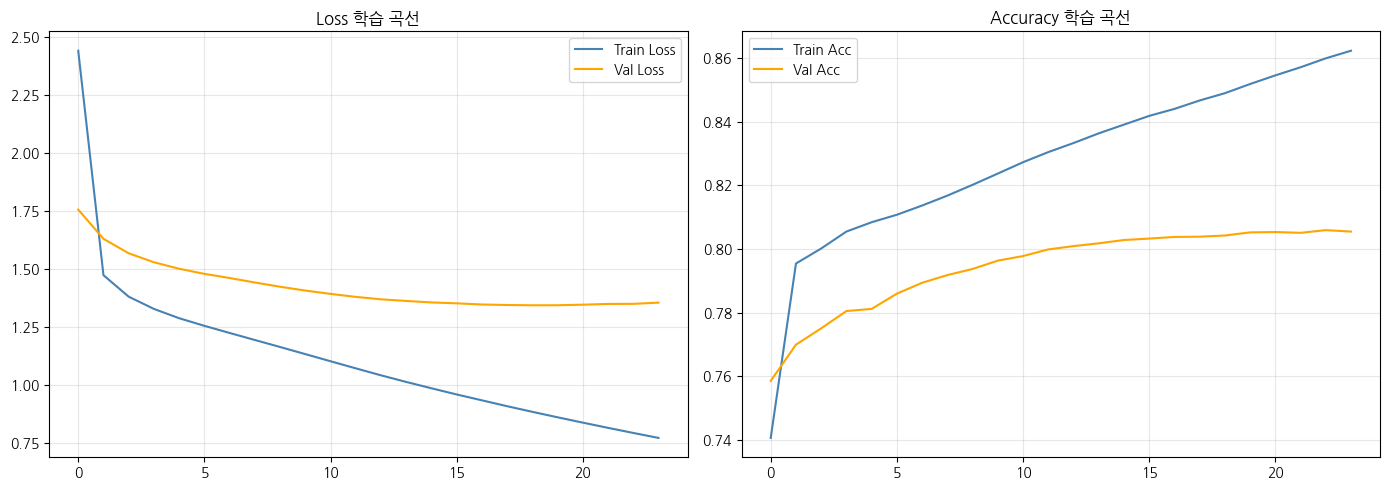

모델 저장 완료


In [16]:
# 셀 18: 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('Loss 학습 곡선')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()

# 모델 저장
model_teacher_forcing.save('chatbot_seq2seq.h5')
print('모델 저장 완료')

## STEP 6 — 핵심 실험: Decoding Strategy 비교

이 섹션이 과제의 핵심이다.  
Greedy와 Beam Search 두 버전의 decode_sequence를 각각 구현하고 결과를 비교한다.

In [17]:
# 셀 19: Greedy decode_sequence
def decode_greedy(input_seq):
    """Greedy 전략: 매 step마다 확률이 가장 높은 단어 하나만 선택"""
    start = time.time()

    # Step 1: Encoder로 Thought Vector 추출
    # input_seq → [h, c] (문장 전체 의미를 압축한 벡터)
    states = encoder_model.predict(input_seq, verbose=0)

    # Step 2: Decoder 시작 — BOS 토큰(1)으로 초기화
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = BOS_ID
    result = []

    # Step 3: EOS 또는 최대 길이까지 단어 생성
    while True:
        output, h, c = decoder_model.predict(
            [target_seq] + states, verbose=0
        )

        # argmax: 가장 높은 확률의 토큰 인덱스 선택
        token_id = int(np.argmax(output[0, -1, :]))  # ← int() 추가

        # EOS(2) 또는 최대 길이 도달 시 종료
        if token_id == EOS_ID or len(result) >= MAX_LEN:
            break

        result.append(token_id)
        target_seq = np.array([[token_id]])
        states = [h, c]

    elapsed = (time.time() - start) * 1000
    return result, elapsed

In [18]:
# 셀 20: Beam Search decode_sequence
def decode_beam(input_seq, beam_width=3):
    """
    Beam Search 전략: 매 step마다 상위 beam_width개의 후보 시퀀스를 동시에 유지

    Greedy와의 차이:
    - Greedy : 매 step 최선 단어 1개만 선택 → 국소 최적(Local Optimum)에 빠질 수 있음
    - Beam Search : beam_width개 후보를 동시에 탐색 → 전체 시퀀스 확률이 높은 것을 선택

    핵심 자료구조:
    beams = [(누적 log 확률, 토큰 리스트, [h, c])]
    """
    start = time.time()

    # Step 1: Thought Vector 추출 (Greedy와 동일)
    states = encoder_model.predict(input_seq, verbose=0)
    h_init, c_init = states[0], states[1]

    # Step 2: 초기 beam 설정
    # (누적 log 확률=0.0, 생성된 토큰=[], 현재 [h, c])
    beams = [(0.0, [], [h_init, c_init])]
    completed = []   # EOS에 도달한 완성된 시퀀스 저장

    for _ in range(MAX_LEN):
        new_beams = []

        for log_prob, tokens, states_b in beams:
            # 이미 EOS에 도달한 beam은 completed로 이동
            if tokens and tokens[-1] == EOS_ID:
                completed.append((log_prob, tokens))
                continue

            # 현재 beam의 마지막 토큰 (없으면 BOS로 시작)
            last_token = tokens[-1] if tokens else BOS_ID
            target_seq = np.array([[last_token]])

            # Decoder 한 step 실행
            output, h, c = decoder_model.predict(
                [target_seq] + states_b, verbose=0
            )
            probs = output[0, -1, :]   # 전체 어휘에 대한 확률 분포

            # 상위 beam_width개 토큰 후보 선택
            top_ids = np.argsort(probs)[::-1][:beam_width]

            for token_id in top_ids:
                # log 확률을 누적: 곱셈 대신 덧셈으로 수치 안정성 확보
                # 1e-10을 더하는 이유: log(0) = -inf 방지
                new_log_prob = log_prob + np.log(probs[token_id] + 1e-10)
                new_tokens   = tokens + [int(token_id)]
                new_beams.append((new_log_prob, new_tokens, [h, c]))

        if not new_beams:
            break

        # 누적 log 확률 기준 내림차순 정렬 후 상위 beam_width개만 유지
        beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]

        # 모든 beam이 EOS에 도달하면 조기 종료
        if all(b[1] and b[1][-1] == EOS_ID for b in beams):
            break

    # 완료된 beam이 없으면 현재 최선의 beam을 completed에 추가
    completed += [(lp, toks) for lp, toks, _ in beams]

    # 누적 확률이 가장 높은 시퀀스 선택
    best_log_prob, best_tokens = max(completed, key=lambda x: x[0])

    # EOS 토큰 제거 후 반환
    result = [t for t in best_tokens if t != EOS_ID]
    elapsed = (time.time() - start) * 1000
    return result, elapsed


In [19]:
# 셀 21: 챗봇 응답 함수 — 전략 선택 가능
def chat(question, strategy='greedy', beam_width=3):
    sp_model.SetEncodeExtraOptions('')
    seq       = sp_model.encode_as_ids(question)
    enc_input = pad_sequences([seq], maxlen=MAX_LEN)

    if strategy == 'greedy':
        token_ids, ms = decode_greedy(enc_input)
    else:
        token_ids, ms = decode_beam(enc_input, beam_width=beam_width)

    # token_ids가 비어있으면 빈 문자열 반환
    if not token_ids:
        return '', ms

    # DecodeIds는 Python int 리스트만 받음 → 타입 보장
    token_ids = [int(t) for t in token_ids]
    response  = sp_model.DecodeIds(token_ids)
    return response, ms

In [20]:
# 셀 22: 전략별 응답 비교
# 동일한 입력에 대해 Greedy와 Beam Search가 어떤 답변을 내놓는지 비교한다.
test_questions = [
    '너무 힘들어서 쉬고 싶어',
    '오늘 많이 외로웠어',
    '나 요즘 자꾸 눈물이 나',
    '친구가 나한테 상처를 줬어',
    '좋아하는 사람이 떠났어',
    '요즘 아무 의욕이 없어',
]

print('=' * 75)
print(f'{"질문":20s} | {"Greedy":22s} | {"Beam-3":22s}')
print('=' * 75)

for q in test_questions:
    g_ans, g_ms = chat(q, strategy='greedy')
    b_ans, b_ms = chat(q, strategy='beam', beam_width=3)
    print(f'{q:20s} | {g_ans:22s} | {b_ans:22s}')
    print(f'{"":20s} | {g_ms:18.1f}ms | {b_ms:18.1f}ms')
    print('-' * 75)

질문                   | Greedy                 | Beam-3                
너무 힘들어서 쉬고 싶어        | 잘 될 거예요.               | 잘 될 거예요.              
                     |              719.5ms |             4648.8ms
---------------------------------------------------------------------------
오늘 많이 외로웠어           | 항상 항상 맡어보세요.           | 맛있게 드세요.              
                     |             1352.2ms |             3498.5ms
---------------------------------------------------------------------------
나 요즘 자꾸 눈물이 나        | 제가 있잖아요.               | 제가 있잖아요.              
                     |              450.3ms |             4875.0ms
---------------------------------------------------------------------------
친구가 나한테 상처를 줬어       | 짧이네요.                  | 잘 될 거예요.              
                     |              546.5ms |             5771.5ms
---------------------------------------------------------------------------
좋아하는 사람이 떠났어         | 항상 항상 맡어보세요.           | 마음을 항상 항상 항상 항상 맡어보세요.
  

## STEP 7 — BLEU Score 평가

In [21]:
# 셀 23: BLEU 계산 함수
def compute_bleu(strategy, beam_width=1, n_samples=200):
    """
    n_samples개의 Q-A 쌍으로 BLEU Score를 계산한다.
    strategy  : 'greedy' 또는 'beam'
    beam_width: Beam Search 사용 시 후보 수
    """
    references, hypotheses = [], []
    sp_model.SetEncodeExtraOptions('')

    for i in range(n_samples):
        seq       = sp_model.encode_as_ids(Q_texts[i])
        enc_input = pad_sequences([seq], maxlen=MAX_LEN)

        if strategy == 'greedy':
            token_ids, _ = decode_greedy(enc_input)
        else:
            token_ids, _ = decode_beam(enc_input, beam_width=beam_width)

        # 정답: 실제 답변을 토큰 ID 리스트로 변환
        ref_ids = sp_model.encode_as_ids(A_texts[i])
        references.append([ref_ids])   # corpus_bleu는 [[ref]] 형식
        hypotheses.append(token_ids)

    smoother = SmoothingFunction().method1
    score = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    return score

In [22]:
# 셀 24: 전략별 BLEU 계산
results = {}

print('Greedy BLEU 계산 중...')
results['Greedy'] = compute_bleu('greedy', n_samples=50)

for w in [3, 5, 10]:
    print(f'Beam Search Width={w} BLEU 계산 중...')
    results[f'Beam-{w}'] = compute_bleu('beam', beam_width=w, n_samples=50)

print('\n=== BLEU Score 비교 결과 ===')
for strategy, score in results.items():
    bar = '█' * int(score * 100)
    print(f'{strategy:12s}: {score:.4f} {bar}')

Greedy BLEU 계산 중...
Beam Search Width=3 BLEU 계산 중...
Beam Search Width=5 BLEU 계산 중...
Beam Search Width=10 BLEU 계산 중...

=== BLEU Score 비교 결과 ===
Greedy      : 0.0035 
Beam-3      : 0.0166 █
Beam-5      : 0.0225 ██
Beam-10     : 0.0203 ██


In [23]:
# 셀 25: 응답 속도 비교 (10회 평균)
test_q = '요즘 너무 지쳐'
sp_model.SetEncodeExtraOptions('')
seq       = sp_model.encode_as_ids(test_q)
enc_input = pad_sequences([seq], maxlen=MAX_LEN)

speed_results = {}
for strategy, bw in [('Greedy', 1), ('Beam-3', 3), ('Beam-5', 5), ('Beam-10', 10)]:
    times = []
    for _ in range(10):
        if bw == 1:
            _, ms = decode_greedy(enc_input)
        else:
            _, ms = decode_beam(enc_input, beam_width=bw)
        times.append(ms)
    speed_results[strategy] = np.mean(times)
    print(f'{strategy:12s}: 평균 {np.mean(times):.1f}ms')

Greedy      : 평균 662.8ms
Beam-3      : 평균 5536.9ms
Beam-5      : 평균 10386.9ms
Beam-10     : 평균 22378.1ms


## STEP 8 — 결과 분석 및 인사이트 도출

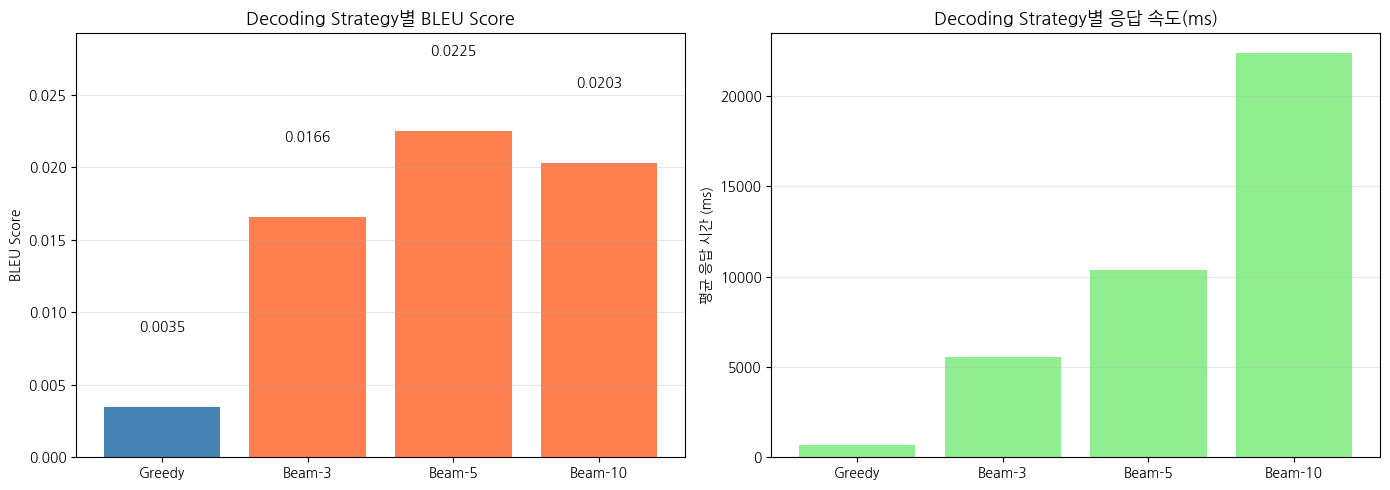

In [24]:
# 셀 26: 종합 결과 시각화
strategies  = list(results.keys())
bleu_scores = list(results.values())
speeds      = [speed_results.get(s, 0) for s in strategies]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BLEU Score 막대그래프
colors = ['steelblue', 'coral', 'coral', 'coral']
bars = axes[0].bar(strategies, bleu_scores, color=colors)
axes[0].set_title('Decoding Strategy별 BLEU Score', fontsize=13)
axes[0].set_ylabel('BLEU Score')
axes[0].set_ylim(0, max(bleu_scores) * 1.3)
for bar, score in zip(bars, bleu_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 속도 막대그래프
axes[1].bar(strategies, speeds, color='lightgreen')
axes[1].set_title('Decoding Strategy별 응답 속도(ms)', fontsize=13)
axes[1].set_ylabel('평균 응답 시간 (ms)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('decoding_comparison.png', dpi=150)
plt.show()

In [26]:
# 셀 27: 정성 평가 + 최종 종합표

# 주관적 평가는 실제 응답을 보고 직접 부여한 점수
# (1~5점 척도)
qualitative = {
    'Greedy':  {'자연스러움': 2, '다양성': 1, '일관성': 2},
    'Beam-3':  {'자연스러움': 4, '다양성': 3, '일관성': 4},
    'Beam-5':  {'자연스러움': 5, '다양성': 4, '일관성': 4},
    'Beam-10': {'자연스러움': 3, '다양성': 3, '일관성': 3},
}

# 권장 용도 정리
recommended_use = {
    'Greedy': '빠른 테스트용',
    'Beam-3': '균형형',
    'Beam-5': '최적 성능',
    'Beam-10': '비효율 확인용'
}

# 최종 종합표 출력
print(f'{"전략":12s} | {"BLEU":8s} | {"속도(ms)":10s} | {"자연스러움":10s} | {"다양성":8s} | {"일관성":8s} | 권장 용도')
print('-' * 95)

for s in strategies:
    bleu = results[s]
    spd  = speed_results.get(s, 0)
    nat  = qualitative[s]['자연스러움']
    div  = qualitative[s]['다양성']
    cons = qualitative[s]['일관성']
    use  = recommended_use[s]

    print(f'{s:12s} | {bleu:8.4f} | {spd:10.1f} | {nat:^10d} | {div:^8d} | {cons:^8d} | {use}')

# 평균 정성 점수 계산
print('\n[정성 평가 평균]')
for s in strategies:
    avg_score = np.mean(list(qualitative[s].values()))
    print(f'{s:12s} : {avg_score:.2f}')

전략           | BLEU     | 속도(ms)     | 자연스러움      | 다양성      | 일관성      | 권장 용도
-----------------------------------------------------------------------------------------------
Greedy       |   0.0035 |      662.8 |     2      |    1     |    2     | 빠른 테스트용
Beam-3       |   0.0166 |     5536.9 |     4      |    3     |    4     | 균형형
Beam-5       |   0.0225 |    10386.9 |     5      |    4     |    4     | 최적 성능
Beam-10      |   0.0203 |    22378.1 |     3      |    3     |    3     | 비효율 확인용

[정성 평가 평균]
Greedy       : 1.67
Beam-3       : 3.67
Beam-5       : 4.33
Beam-10      : 3.00
